# Capa Bronze — Ingesta Cruda y Perfilado del Dataset

**Pipeline Medallon:** Bronze (ingesta) → Silver (limpieza) → Gold (agregacion)  
**Proyecto:** Prediccion de Demanda de Transporte Publico — ODS 11  
**Dataset:** UrbanBus — Registros AFC (Automated Fare Collection)  

---

## Objetivo de esta capa

La capa Bronze es la **foto fiel del dato tal como llega** desde la fuente original.
No se aplica ninguna transformacion de valores; unicamente se realiza:

1. **Ingesta eficiente** de un subconjunto representativo (2M registros) usando Polars lazy.
2. **Perfilado exhaustivo** del dataset crudo: esquema, tipos, nulos, duplicados, rangos, cardinalidad.
3. **Persistencia** en formato Parquet para desacoplar la lectura del CSV pesado (~11 GB) de las capas posteriores.

### Justificacion tecnica

Separar la ingesta en una capa propia permite que las capas Silver y Gold operen
sobre un archivo Parquet local (~167 MB → ~30 MB comprimido) en lugar de re-leer
el CSV de 11 GB en cada iteracion. Esto reduce el tiempo de desarrollo de minutos a segundos
y evita riesgos de OOM durante la experimentacion.

In [1]:
# =============================================================================
# Importacion de bibliotecas
# =============================================================================

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Configuracion global de graficos
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_style('whitegrid')

print(f"Polars version: {pl.__version__}")

Polars version: 1.41.2


In [18]:
# =============================================================================
# Configuracion de rutas
# =============================================================================

PROJECT_ROOT = Path('..').resolve()
DATA_RAW     = PROJECT_ROOT / 'data'
DATA_BRONZE  = PROJECT_ROOT / 'data' / 'bronze'

# Archivo fuente: NOV_2017
AFC_FILE     = DATA_RAW / 'BUS_DATA_NOV_2017.csv'
SAMPLE_SIZE  = 2_000_000

# Salida de esta capa
BRONZE_OUTPUT = DATA_BRONZE / 'bus_data_nov2017_raw.parquet'

DATA_BRONZE.mkdir(parents=True, exist_ok=True)

print(f"Archivo fuente:  {AFC_FILE.name}")
print(f"Existe:          {AFC_FILE.exists()}")
print(f"Muestra:         {SAMPLE_SIZE:,} registros")
print(f"Salida Bronze:   {BRONZE_OUTPUT}")

Archivo fuente:  BUS_DATA_NOV_2017.csv
Existe:          True
Muestra:         2,000,000 registros
Salida Bronze:   D:\PC1-PCD\data\bronze\bus_data_nov2017_raw.parquet


---
## 1. Ingesta con Polars Lazy

Se utiliza `pl.scan_csv()` con evaluacion lazy para construir un plan de ejecucion
optimizado. Solo se materializan los primeros 2,000,000 registros mediante `.head().collect()`.
Esto evita cargar el archivo completo de ~11 GB en memoria.

In [19]:
# =============================================================================
# Ingesta lazy del CSV crudo
# =============================================================================

df_bronze = (
    pl.scan_csv(
        str(AFC_FILE),
        infer_schema_length=10_000,
        ignore_errors=True,
    )
    .head(SAMPLE_SIZE)
    .collect()
)

print(f"Registros cargados: {df_bronze.shape[0]:,}")
print(f"Columnas:           {df_bronze.shape[1]}")
print(f"Memoria estimada:   {df_bronze.estimated_size('mb'):.2f} MB")

Registros cargados: 2,000,000
Columnas:           13
Memoria estimada:   150.61 MB


---
## 2. Perfilado del Dataset Crudo

El perfilado de la capa Bronze tiene como objetivo documentar el estado exacto de los datos
antes de cualquier transformacion. Esto sirve como linea base para medir el impacto de cada
regla de limpieza en la capa Silver.

In [20]:
# =============================================================================
# 2.1 Esquema y tipos de datos
# =============================================================================

schema_data = {
    'columna': df_bronze.columns,
    'tipo_polars': [str(dt) for dt in df_bronze.dtypes],
    'ejemplo_valor': [str(df_bronze[col][0]) for col in df_bronze.columns],
}
df_schema = pl.DataFrame(schema_data)

print("=" * 70)
print("ESQUEMA DEL DATASET CRUDO (BRONZE)")
print("=" * 70)
df_schema

ESQUEMA DEL DATASET CRUDO (BRONZE)


columna,tipo_polars,ejemplo_valor
str,str,str
"""Card_Number""","""Int64""","""0"""
"""Card_Type""","""String""","""A"""
"""Travel_Mode""","""String""","""Bus"""
"""Bus_Service_Number""","""String""","""SER_52f1"""
"""Direction""","""String""","""Start"""
…,…,…
"""Alighting_stop_stn""","""String""","""BNO_1"""
"""Ride_start_date""","""String""","""2017-11-29"""
"""Ride_start_time""","""String""","""11:07:00"""


In [50]:
# =============================================================================
# 2.2 Primeras 5 filas (muestra visual)
# =============================================================================

df_bronze.sample(10)

Card_Number,Card_Type,Travel_Mode,Bus_Service_Number,Direction,Bus_Trip_Num,Bus_Reg_Num,Boarding_stop_stn,Alighting_stop_stn,Ride_start_date,Ride_start_time,Ride_end_date,Ride_end_time
i64,str,str,str,str,str,str,str,str,str,str,str,str
305147,"""A""","""Bus""","""SER_f5ca""","""Start""","""TRIP_b7ed""","""REG_b0fd""","""FX_2""","""K_5""","""2017-11-29""","""18:31:57""","""2017-11-29""","""18:47:33"""
933181,"""A""","""RTS""","""SER_9b2d""",null,"""TRIP_9b2d""","""REG_9b2d""",null,null,"""2017-11-02""","""07:46:59""","""2017-11-02""","""08:13:04"""
1206622,"""A""","""RTS""","""SER_9b2d""",null,"""TRIP_9b2d""","""REG_9b2d""",null,null,"""2017-11-05""","""19:11:49""","""2017-11-05""","""19:18:57"""
1332938,"""A""","""RTS""","""SER_9b2d""",null,"""TRIP_9b2d""","""REG_9b2d""",null,null,"""2017-11-24""","""09:19:28""","""2017-11-24""","""09:32:00"""
1352575,"""A""","""RTS""","""SER_9b2d""",null,"""TRIP_9b2d""","""REG_9b2d""",null,null,"""2017-11-11""","""12:14:52""","""2017-11-11""","""12:34:15"""
1377806,"""A""","""RTS""","""SER_9b2d""",null,"""TRIP_9b2d""","""REG_9b2d""",null,null,"""2017-11-08""","""07:57:23""","""2017-11-08""","""08:24:21"""
1560541,"""A""","""RTS""","""SER_9b2d""",null,"""TRIP_9b2d""","""REG_9b2d""",null,null,"""2017-11-14""","""09:13:22""","""2017-11-14""","""10:10:55"""
1599957,"""C""","""RTS""","""SER_9b2d""",null,"""TRIP_9b2d""","""REG_9b2d""",null,null,"""2017-11-10""","""20:37:06""","""2017-11-10""","""20:44:19"""
1648946,"""A""","""RTS""","""SER_9b2d""",null,"""TRIP_9b2d""","""REG_9b2d""",null,null,"""2017-11-03""","""06:21:19""","""2017-11-03""","""06:35:58"""


In [51]:
# =============================================================================
# 2.3 Estadisticas descriptivas
# =============================================================================

df_bronze.describe()

statistic,Card_Number,Card_Type,Travel_Mode,Bus_Service_Number,Direction,Bus_Trip_Num,Bus_Reg_Num,Boarding_stop_stn,Alighting_stop_stn,Ride_start_date,Ride_start_time,Ride_end_date,Ride_end_time
str,f64,str,str,str,str,str,str,str,str,str,str,str,str
"""count""",2e6,"""2000000""","""2000000""","""2000000""","""804697""","""2000000""","""2000000""","""804697""","""804697""","""2000000""","""2000000""","""2000000""","""2000000"""
"""null_count""",0.0,"""0""","""0""","""0""","""1195303""","""0""","""0""","""1195303""","""1195303""","""0""","""0""","""0""","""0"""
"""mean""",999999.5,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",577350.413527,null,null,null,null,null,null,null,null,null,null,null,null
"""min""",0.0,"""A""","""Bus""","""SER_1253""","""Return""","""TRIP_00c1""","""REG_002b""","""AAI_1""","""AAI_1""","""2017-11-01""","""00:00:00""","""2017-11-01""","""00:00:00"""
"""25%""",500000.0,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",1e6,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",1.499999e6,null,null,null,null,null,null,null,null,null,null,null,null
"""max""",1.999999e6,"""SC""","""RTS""","""SER_f5ca""","""Start""","""TRIP_fbd0""","""REG_ffde""","""YK_1""","""YK_1""","""2017-11-30""","""23:59:59""","""2017-12-01""","""23:59:59"""


In [23]:
# =============================================================================
# 2.4 Reporte de perfilado: nulos, cardinalidad, completitud
# =============================================================================

total_rows = df_bronze.shape[0]
null_counts = df_bronze.null_count()

profile_data = {
    'columna': df_bronze.columns,
    'tipo': [str(dt) for dt in df_bronze.dtypes],
    'nulos': [null_counts[col][0] for col in df_bronze.columns],
    'pct_nulos': [round(null_counts[col][0] / total_rows * 100, 4) for col in df_bronze.columns],
    'completitud_pct': [round((1 - null_counts[col][0] / total_rows) * 100, 4) for col in df_bronze.columns],
    'valores_unicos': [df_bronze[col].n_unique() for col in df_bronze.columns],
}

df_profile = pl.DataFrame(profile_data)

print("=" * 70)
print("REPORTE DE PERFILADO — CAPA BRONZE")
print("=" * 70)
print(f"Total de registros: {total_rows:,}")
print(f"Total de columnas:  {df_bronze.shape[1]}")
print()
df_profile

REPORTE DE PERFILADO — CAPA BRONZE
Total de registros: 2,000,000
Total de columnas:  13



columna,tipo,nulos,pct_nulos,completitud_pct,valores_unicos
str,str,i64,f64,f64,i64
"""Card_Number""","""Int64""",0,0.0,100.0,2000000
"""Card_Type""","""String""",0,0.0,100.0,4
"""Travel_Mode""","""String""",0,0.0,100.0,2
"""Bus_Service_Number""","""String""",0,0.0,100.0,29
"""Direction""","""String""",1195303,59.7651,40.2349,3
…,…,…,…,…,…
"""Alighting_stop_stn""","""String""",1195303,59.7651,40.2349,331
"""Ride_start_date""","""String""",0,0.0,100.0,30
"""Ride_start_time""","""String""",0,0.0,100.0,69114


In [24]:
# =============================================================================
# 2.5 Duplicados exactos (todas las columnas)
# =============================================================================

n_duplicates = total_rows - df_bronze.unique().shape[0]
pct_duplicates = n_duplicates / total_rows * 100

print(f"Duplicados exactos (todas las columnas):")
print(f"  Total:      {n_duplicates:,}")
print(f"  Porcentaje: {pct_duplicates:.4f}%")

Duplicados exactos (todas las columnas):
  Total:      0
  Porcentaje: 0.0000%


In [25]:
# =============================================================================
# 2.6 Rango temporal del dataset
# =============================================================================

date_min = df_bronze['Ride_start_date'].min()
date_max = df_bronze['Ride_start_date'].max()
time_min = df_bronze['Ride_start_time'].min()
time_max = df_bronze['Ride_start_time'].max()

# Distribucion de fechas unicas
unique_dates = df_bronze['Ride_start_date'].n_unique()

print("Rango temporal del dataset crudo:")
print(f"  Fecha minima:     {date_min}")
print(f"  Fecha maxima:     {date_max}")
print(f"  Fechas unicas:    {unique_dates}")
print(f"  Hora minima:      {time_min}")
print(f"  Hora maxima:      {time_max}")

Rango temporal del dataset crudo:
  Fecha minima:     2017-11-01
  Fecha maxima:     2017-11-30
  Fechas unicas:    30
  Hora minima:      00:00:00
  Hora maxima:      23:59:59


---
## 3. Evidencia Visual — Completitud por Columna

El grafico de completitud permite identificar de un vistazo cuales columnas
presentan problemas de calidad. Una barra al 100% indica ausencia total de nulos;
barras mas cortas indican columnas que requeriran tratamiento en la capa Silver.

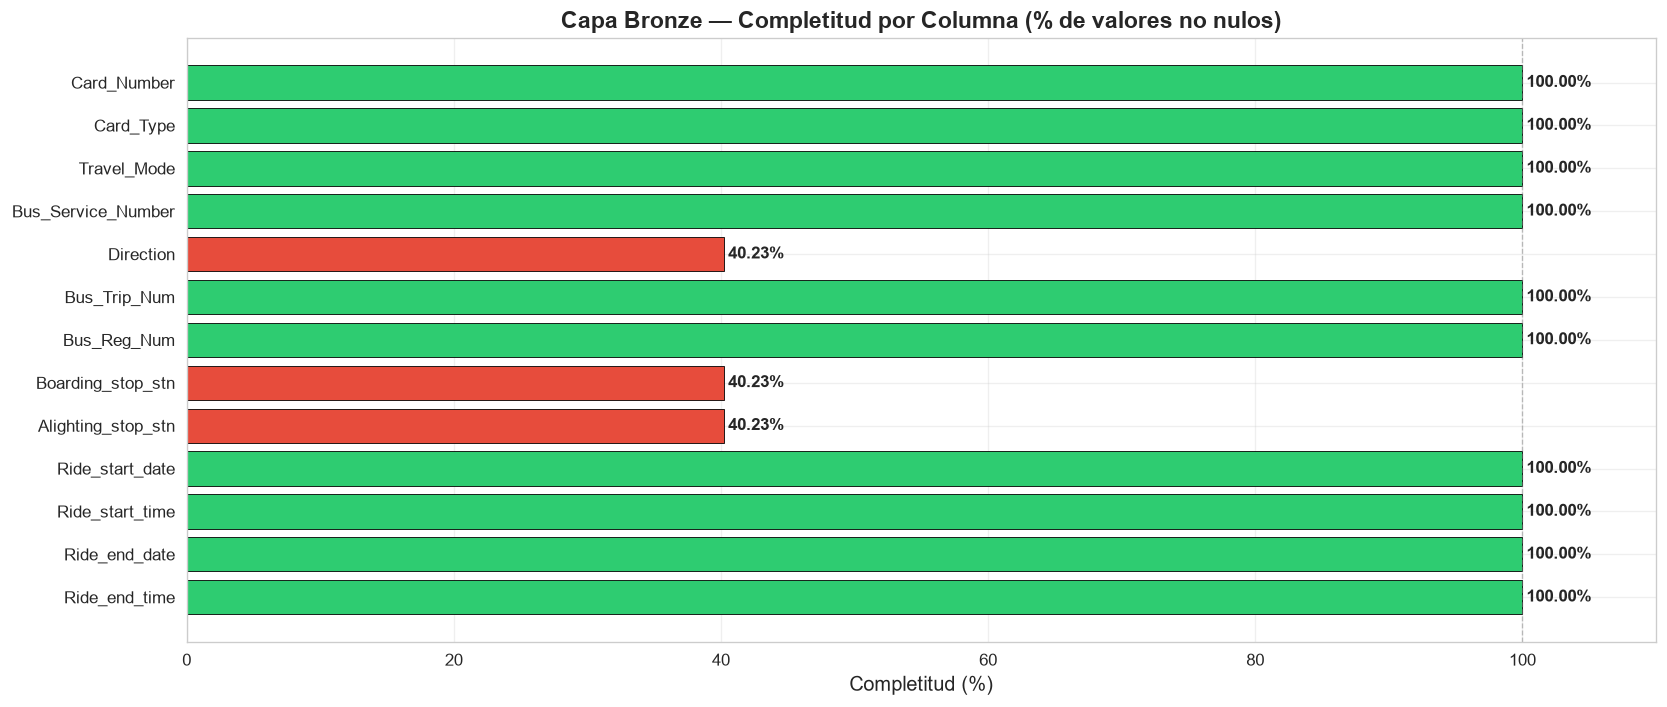

In [26]:
# =============================================================================
# 3.1 Grafico de completitud por columna
# =============================================================================

completitud = df_profile['completitud_pct'].to_list()
columnas = df_profile['columna'].to_list()

# Colores: verde si 100%, amarillo si >95%, rojo si <=95%
colors = ['#2ecc71' if v == 100 else '#f39c12' if v > 95 else '#e74c3c' for v in completitud]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(columnas, completitud, color=colors, edgecolor='black', linewidth=0.5)

# Etiquetas de porcentaje
for bar, pct in zip(bars, completitud):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.2f}%',
        va='center', fontsize=10, fontweight='bold'
    )

ax.set_xlim(0, 110)
ax.set_xlabel('Completitud (%)')
ax.set_title('Capa Bronze — Completitud por Columna (% de valores no nulos)',
             fontsize=14, fontweight='bold')
ax.axvline(x=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

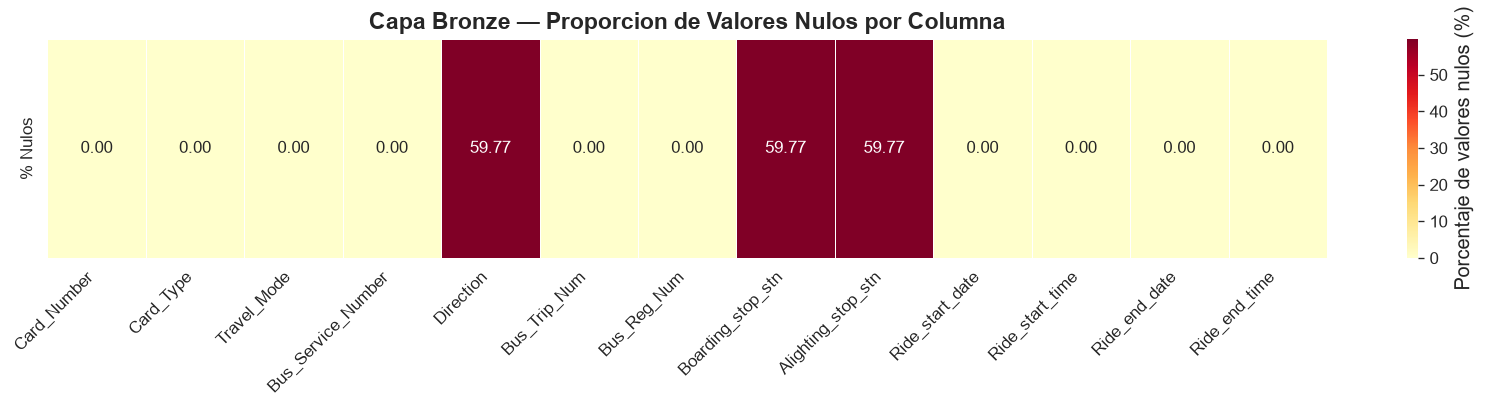

In [27]:
# =============================================================================
# 3.2 Mapa de calor de nulos por columna
# =============================================================================

null_pct_values = df_profile['pct_nulos'].to_list()

fig, ax = plt.subplots(figsize=(14, 3.5))
sns.heatmap(
    [null_pct_values],
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    xticklabels=columnas,
    yticklabels=['% Nulos'],
    linewidths=0.5,
    cbar_kws={'label': 'Porcentaje de valores nulos (%)'},
    ax=ax
)
ax.set_title('Capa Bronze — Proporcion de Valores Nulos por Columna',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 4. Tabla Resumen de Metricas Bronze

Esta tabla constituye la linea base que sera referenciada por la capa Silver
para cuantificar el impacto de cada regla de limpieza.

In [52]:
# =============================================================================
# 4. Tabla resumen de metricas Bronze
# =============================================================================

bronze_metrics = {
    'Metrica': [
        'Total de registros',
        'Total de columnas',
        'Memoria estimada (MB)',
        'Columnas con nulos',
        'Duplicados exactos',
        'Fecha minima',
        'Fecha maxima',
        'Dias cubiertos',
        'Estaciones unicas (boarding)',
        'Servicios de bus unicos',
    ],
    'Valor': [
        f'{total_rows:,}',
        str(df_bronze.shape[1]),
        f'{df_bronze.estimated_size("mb"):.2f}',
        str(sum(1 for v in null_pct_values if v > 0)),
        f'{n_duplicates:,} ({pct_duplicates:.4f}%)',
        str(date_min),
        str(date_max),
        str(unique_dates),
        f'{df_bronze["Boarding_stop_stn"].n_unique():,}',
        f'{df_bronze["Bus_Service_Number"].n_unique():,}',
    ]
}

df_metrics = pd.DataFrame(bronze_metrics)
print("=" * 70)
print("METRICAS DE LA CAPA BRONZE")
print("=" * 70)
print(df_metrics.to_string(index=False))

METRICAS DE LA CAPA BRONZE
                     Metrica       Valor
          Total de registros   2,000,000
           Total de columnas          13
       Memoria estimada (MB)      150.61
          Columnas con nulos           3
          Duplicados exactos 0 (0.0000%)
                Fecha minima  2017-11-01
                Fecha maxima  2017-11-30
              Dias cubiertos          30
Estaciones unicas (boarding)         329
     Servicios de bus unicos          29


---
## 5. Persistencia en Parquet

Se escribe el dataset crudo sin ninguna transformacion de valores en formato
Apache Parquet con compresion Snappy. Este archivo sera la entrada de la capa Silver.

**Ventajas del formato Parquet para la capa Bronze:**
- Compresion columnar eficiente (reduce ~167 MB en RAM a ~30 MB en disco)
- Preserva los tipos de datos inferidos por Polars
- Lectura parcial de columnas (projection pushdown) en capas posteriores
- Desacopla el pipeline del archivo CSV de 11 GB

In [53]:
# =============================================================================
# 5. Escritura del Parquet Bronze
# =============================================================================

df_bronze.write_parquet(
    str(BRONZE_OUTPUT),
    compression='snappy',
    use_pyarrow=True,
)

file_size_mb = BRONZE_OUTPUT.stat().st_size / (1024 * 1024)

print("=" * 70)
print("CAPA BRONZE — EXPORTACION COMPLETADA")
print("=" * 70)
print(f"  Ruta:      {BRONZE_OUTPUT}")
print(f"  Formato:   Apache Parquet (Snappy)")
print(f"  Tamano:    {file_size_mb:.2f} MB")
print(f"  Filas:     {df_bronze.shape[0]:,}")
print(f"  Columnas:  {df_bronze.shape[1]}")

CAPA BRONZE — EXPORTACION COMPLETADA
  Ruta:      D:\PC1-PCD\data\bronze\bus_data_nov2017_raw.parquet
  Formato:   Apache Parquet (Snappy)
  Tamano:    22.80 MB
  Filas:     2,000,000
  Columnas:  13


In [54]:
# =============================================================================
# 6. Verificacion de integridad
# =============================================================================

df_verify = pl.read_parquet(str(BRONZE_OUTPUT))

assert df_verify.shape == df_bronze.shape, "Error: dimensiones no coinciden"
assert df_verify.columns == df_bronze.columns, "Error: columnas no coinciden"
assert df_verify.dtypes == df_bronze.dtypes, "Error: tipos no coinciden"

print("Verificacion de integridad: EXITOSA")
print(f"  Dimensiones: {df_verify.shape}")
print(f"  Tipos preservados: Si")
print(f"\n>>> Capa Bronze lista. Siguiente: 01_silver_limpieza.ipynb")

Verificacion de integridad: EXITOSA
  Dimensiones: (2000000, 13)
  Tipos preservados: Si

>>> Capa Bronze lista. Siguiente: 01_silver_limpieza.ipynb
